## GARCH(1,1) — Generalized Autoregressive Conditional Heteroskedasticity

A statistical model used to estimate and forecast the volatility of financial time series, particularly where volatility is **time-varying** and exhibits **clustering** — periods of high volatility are followed by high volatility, and calm by calm. It models the conditional variance as:

$$\sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

- **ω (omega):** baseline volatility component (long-run average variance).
- **α (alpha):** sensitivity to recent shocks (squared returns).
- **β (beta):** persistence of volatility (how much past volatility carries into the present).

The model is stationary — and the long-run variance $\omega/(1-\alpha-\beta)$ is well defined — only when $\alpha + \beta < 1$.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
ticker = "NKE"

start_date = "2021-01-01"
end_date = "2026-01-01"

data = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Daily simple returns (the resample line is left as a reference for switching to weekly)
daily_returns = data["Close"].pct_change().dropna()
# weekly_returns = data["Close"].pct_change().resample("W").last().dropna()

In [4]:
daily_returns.head()

Ticker,NKE
Date,
2021-01-05,0.008065
2021-01-06,0.007931
2021-01-07,0.018265
2021-01-08,0.009658
2021-01-11,0.004783


In [5]:
log_ret = np.log(1 + daily_returns) * 100  # x100 improves the numerical stability of the estimation
print(f"Number of observations: {len(log_ret)}")

Number of observations: 1254


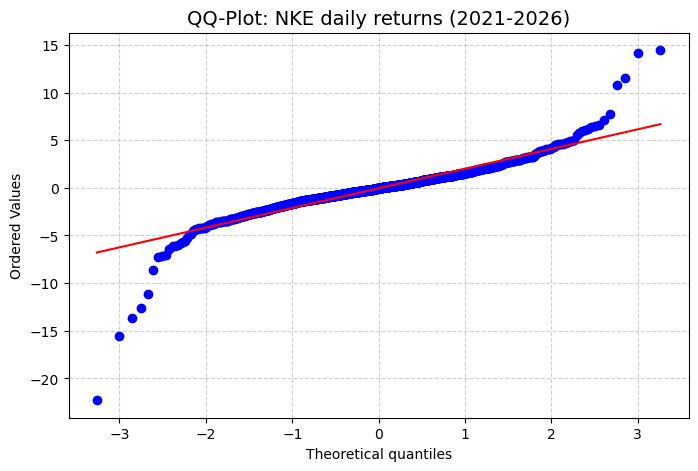

In [6]:
# A QQ-plot checks which distribution the returns follow (normal, Student's t, skew-t, GED).

plt.figure(figsize=(8, 5))
stats.probplot(log_ret.values.flatten(), dist="norm", plot=plt)
plt.title("QQ-Plot: NKE daily returns (2021-2026)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
# The QQ-plot shows the returns are clearly NOT normally distributed: both tails are heavier
# than the normal, and the lower tail is heavier than the upper (negative shocks larger than
# positive ones). We therefore fit GARCH(1,1) with a fat-tailed Student's t distribution.
# Note: the asymmetry suggests a skew-t would be an even better fit.

model = arch_model(log_ret, vol="GARCH", p=1, q=1, dist="t")
result = model.fit(update_freq=5)
print(result.summary())

Iteration:      5,   Func. Count:     38,   Neg. LLF: 3448.6684897729056
Iteration:     10,   Func. Count:     70,   Neg. LLF: 2561.4145184708036
Iteration:     15,   Func. Count:    101,   Neg. LLF: 2560.900396265505
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2560.900396265505
            Iterations: 16
            Function evaluations: 106
            Gradient evaluations: 16
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          NKE   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2560.90
Distribution:      Standardized Student's t   AIC:                           5131.80
Method:                  Maximum Likelihood   BIC:                           5157.47
                                              No. Observations

In [8]:
result.params

mu         -0.046329
omega       0.213463
alpha[1]    0.036382
beta[1]     0.918396
nu          3.440841
Name: params, dtype: float64

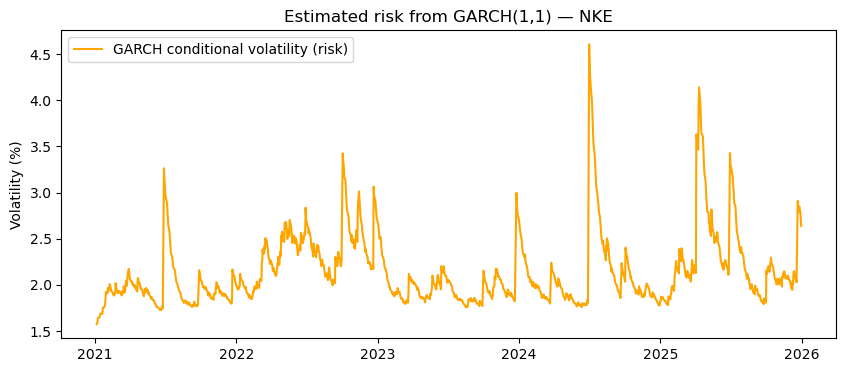

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(result.conditional_volatility, color='orange', label='GARCH conditional volatility (risk)')
plt.title("Estimated risk from GARCH(1,1) — NKE")
plt.ylabel("Volatility (%)")
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


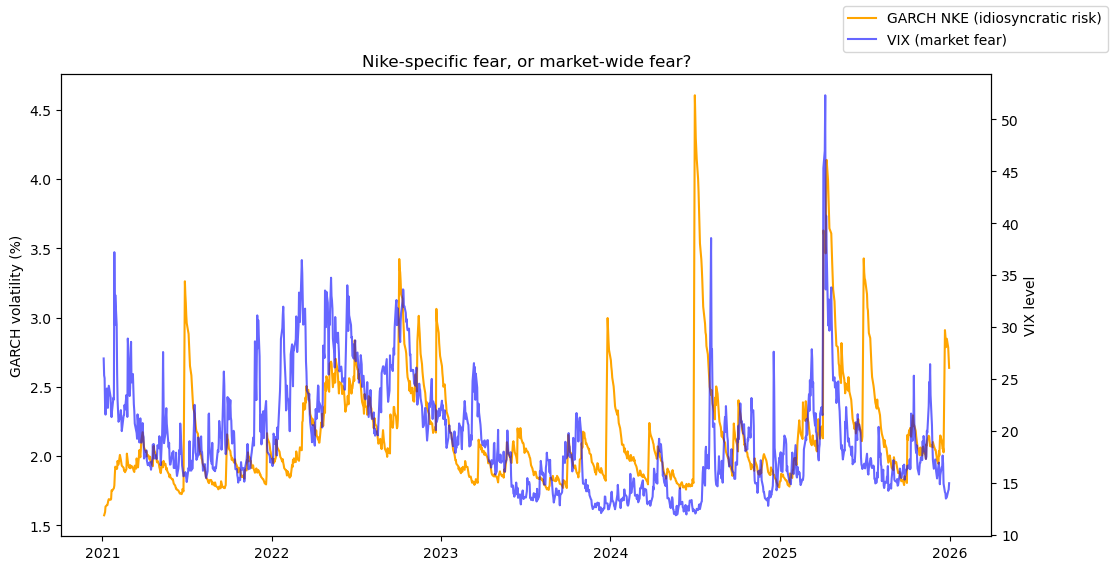

In [10]:
# Is the volatility spike Nike-specific, or is the whole market scared?
# We overlay NKE's GARCH volatility on the VIX (the market's "fear gauge").

vix_data = yf.download("^VIX", start="2021-01-01", end="2026-01-01")['Close']

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(result.conditional_volatility, color='orange', label='GARCH NKE (idiosyncratic risk)')
ax1.set_ylabel('GARCH volatility (%)')

ax2 = ax1.twinx()  # second y-axis
ax2.plot(vix_data, color='blue', alpha=0.6, label='VIX (market fear)')
ax2.set_ylabel('VIX level')

plt.title("Nike-specific fear, or market-wide fear?")
fig.legend(loc="upper right")
plt.show()